📊 データ取得成功: 70 件


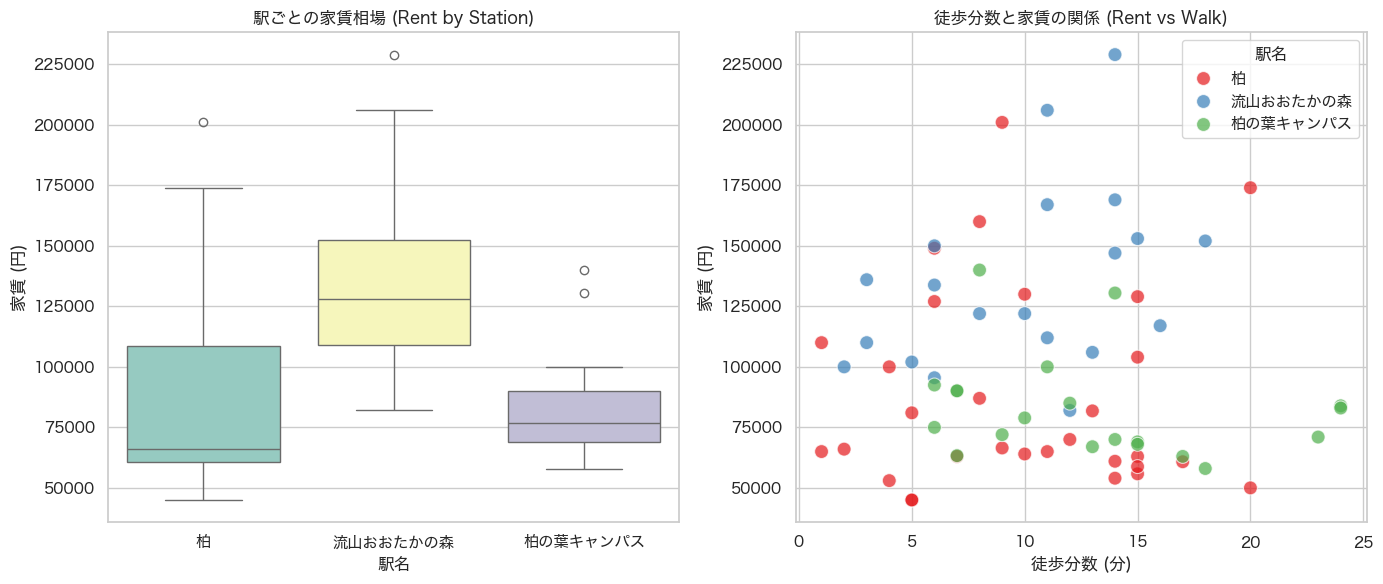

✅ グラフ作成完了！ 日本語が表示されているはずです。


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. 日本語フォントの設定（Mac用）
plt.rcParams['font.family'] = 'Hiragino Sans' 

# 2. データベースファイルを自動で探す
current_dir = Path.cwd()
target_file = None
possible_paths = ["Final assignment/db/rent.db", "db/rent.db", "src/scraping/rent.db", "rent.db"]

search_dir = current_dir
for _ in range(5):
    for p in possible_paths:
        check_path = search_dir / p
        if check_path.exists():
            target_file = check_path
            break
    if target_file: break
    search_dir = search_dir.parent

if target_file is None:
    print("❌ エラー: DBが見つかりません。")
else:
    # 3. データ読み込み
    conn = sqlite3.connect(str(target_file))
    df = pd.read_sql("SELECT * FROM rent_properties", conn)
    conn.close()

    print(f"📊 データ取得成功: {len(df)} 件")

    if len(df) > 0:
        # 4. グラフ作成
        sns.set(style="whitegrid", font="Hiragino Sans") 
        plt.figure(figsize=(14, 6))

        # 左側：駅ごとの家賃比較
        plt.subplot(1, 2, 1)
        sns.boxplot(x='station', y='rent', data=df, hue='station', palette="Set3", legend=False)
        plt.title('駅ごとの家賃相場 (Rent by Station)')
        plt.xlabel('駅名')
        plt.ylabel('家賃 (円)')

        # 右側：徒歩分数と家賃の関係
        plt.subplot(1, 2, 2)
        sns.scatterplot(x='walk_min', y='rent', hue='station', data=df, palette="Set1", s=100, alpha=0.7)
        plt.title('徒歩分数と家賃の関係 (Rent vs Walk)')
        plt.xlabel('徒歩分数 (分)')
        plt.ylabel('家賃 (円)')
        plt.legend(title='駅名')

        plt.tight_layout()
        plt.show()
        print("✅ グラフ作成完了！ 日本語が表示されているはずです。")
    else:
        print("⚠️ データがありません。")

In [5]:
%pip install pandas matplotlib seaborn

  Using cached pandas-3.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.0-cp312-cp312-macosx_11_0_arm64.whl (9.9 MB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3